In [18]:
import itertools as it

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import yfinance as yf
from statsmodels.tsa.stattools import coint
import warnings

# Testing over a set of tech companies; the search can easily be
# extended by adding more companies.
COMPANIES = ['NVDA', 'AAPL', 'MSFT', 'AVGO', 'AMD', 'GOOG', 'AMZN', 'META']

# Stock prices of the companies over a 5 year period at close.
realisation_matrix = yf.download(COMPANIES, start="2021-07-29",end="2026-07-29")['Close']

[*********************100%***********************]  8 of 8 completed


In [2]:
realisation_matrix.head()

Ticker,AAPL,AMD,AMZN,AVGO,GOOG,META,MSFT,NVDA
Date,,,,,,,,
2021-07-29,141.962875,102.949997,179.996002,44.072540,135.347198,355.200806,274.953125,19.594221
2021-07-30,142.177338,106.190002,166.379501,44.189987,134.039215,353.198364,273.427277,19.431782
2021-08-02,141.845917,108.629997,166.574005,44.124428,134.801025,348.886230,273.340790,19.681921
2021-08-03,143.639420,112.559998,168.311996,44.316521,135.088959,348.182404,275.548157,19.746698
2021-08-04,143.239777,118.769997,167.735992,44.408474,134.839661,355.795563,274.962677,20.204119


In [3]:
# Dropping incomplete entries, and taking logs for scale invariance.
# Splitting the data 80/20 for training/testing the model.
clean_matrix = realisation_matrix.dropna()
split = int(len(clean_matrix) * 0.80)
train_matrix = clean_matrix.iloc[:split]
test_matrix = clean_matrix.iloc[split:]

clean_matrix_log = np.log(clean_matrix)
train_matrix_log = clean_matrix_log.iloc[:split]
test_matrix_log = clean_matrix_log.iloc[split:]

In [4]:
def calculate_half_life(spread):
    """Return the days taken for a divergence from the mean to halve.

    Achieved via an Ornstein-Uhlenbeck process.
    """
    ds = spread.diff()       # Change in spread (Delta S_t)
    lag = spread.shift(1)    # Lagged spread (S_{t-1})

    # Create a dataframe to drop NaNs for correct alignment.
    df = pd.DataFrame({'ds': ds, 'lag': lag}).dropna()

    # Fit OLS regression: Delta S_t = alpha + gamma * S_{t-1} + e_t
    model = sm.OLS(df['ds'], sm.add_constant(df['lag'])).fit()
    gamma = model.params.iloc[1]

    # Half life is valid if and only if gamma < 0.
    return -np.log(2) / gamma if gamma < 0 else np.inf

In [5]:
def pair(prices_logged, p_threshold=0.05):
    """Find cointegrated pairs with a p-value under the threshold.

    Takes logged prices as input. Both directions of the model are
    tested: the pair is screened on the worse direction and the hedge
    ratio is fitted in the better one.
    """
    results = []

    # Iterating over each unique pair of stocks.
    for ticker_a, ticker_b in it.combinations(prices_logged.columns, 2):
        y_unordered = prices_logged[ticker_a]
        x_unordered = prices_logged[ticker_b]

        # Engle-Granger test; a low p-value is evidence of a long term
        # equilibrium.
        p_value1 = coint(y_unordered, x_unordered)[1]
        p_value2 = coint(x_unordered, y_unordered)[1]
        if p_value1 >= p_value2:
            p_value = p_value1
            y = x_unordered
            x = y_unordered
            stock_y = ticker_b
            stock_x = ticker_a
        else:
            p_value = p_value2
            y = y_unordered
            x = x_unordered
            stock_y = ticker_a
            stock_x = ticker_b

        if p_value < p_threshold:
            # Computing the half life and beta (hedge ratio) of the
            # model y = alpha + beta * x (static cointegrating
            # regression).
            model = sm.OLS(y, sm.add_constant(x)).fit()
            alpha = model.params.iloc[0]
            beta = model.params.iloc[1]
            spread = y - (alpha + beta * x)

            # Use the calculated spread to get the pair's half life.
            hl = calculate_half_life(spread)
            results.append({
                'Pair': f'{stock_y} - {stock_x}',
                'p_value': round(p_value, 4),
                'beta': round(beta, 4),
                'half_life_days': round(hl, 1),
            })

    return (pd.DataFrame(results)
            .sort_values('p_value')
            .reset_index(drop=True))

In [6]:
pair(train_matrix_log)

,Pair,p_value,beta,half_life_days
0,GOOG - AMZN,0.0013,0.7722,18.3
1,MSFT - META,0.0292,0.3935,33.2
2,MSFT - NVDA,0.0357,0.2597,27.6


In [7]:
def kalman_filter(x_logged, y_logged, delta_alpha=1e-4, delta_beta=1e-4,
                  R=1, warmup=30, z_window=30, a=None, b=None, P=None):
    """Filter a pair of stocks into alpha, beta, spread and z-score.

    Takes logged prices as input and returns a series of betas (hedge
    ratios) with the corresponding spread and z-score.

    x_logged, y_logged: logged prices of stock x and stock y.
    delta_alpha, delta_beta: process variances, dictating how fast
        alpha and beta can change.
    R: measurement noise variance, representing the level of
        background noise.
    warmup: number of days used to train the initial beta. Two modes
        are supported: warmup > 0 seeds the state by OLS, warmup = 0
        starts from the supplied a, b and P.
    z_window: lookback window used to calculate the z-score.
    a, b: initial alpha and beta.
    P: corresponding initial estimate of the error covariance.
    """
    n = len(x_logged)
    alphas = np.zeros(n)
    betas = np.zeros(n)
    spreads = np.zeros(n)

    if warmup > 0:
        # Initialise parameters over the warmup period using OLS.
        warmup_x = sm.add_constant(x_logged.iloc[:warmup])
        warmup_y = y_logged.iloc[:warmup]
        ols = sm.OLS(warmup_y, warmup_x).fit()
        theta = ols.params.values.astype(float)     # [alpha, beta]
        # cov_params maintains the alpha-beta covariance.
        P = ols.cov_params().values.astype(float)
        alphas[:warmup] = theta[0]
        betas[:warmup] = theta[1]
        spreads[:warmup] = warmup_y - (
            theta[0] + theta[1] * x_logged.iloc[:warmup])
    else:
        # Starting from the inputted parameters.
        theta = np.array([a, b], dtype=float)
        P = np.asarray(P, dtype=float)

    # Process noise covariance.
    Q = np.diag([delta_alpha / (1 - delta_alpha),
                 delta_beta / (1 - delta_beta)])

    for t in range(warmup, n):
        xt = x_logged.iloc[t]
        yt = y_logged.iloc[t]
        H = np.array([1.0, xt])         # Observation vector

        e = yt - H @ theta              # One-step-ahead forecast error
        S = H @ P @ H + R               # Innovation variance
        K = (P @ H) / S                 # Kalman gain (2-vector)
        theta = theta + K * e           # Joint update of alpha and beta
        P = P - np.outer(K, H @ P)      # (I - KH) P
        P = (P + P.T) / 2 + Q           # Symmetrise, then add Q

        alphas[t] = theta[0]
        betas[t] = theta[1]
        spreads[t] = e

    alpha_series = pd.Series(alphas, index=x_logged.index, name='Alpha')
    beta_series = pd.Series(betas, index=x_logged.index, name='Beta')
    spread_series = pd.Series(spreads, index=x_logged.index, name='Spread')

    # Statistics for the z-score.
    rolling_mean = spread_series.rolling(window=z_window).mean()
    rolling_std = spread_series.rolling(window=z_window).std()
    z_score_series = (spread_series - rolling_mean) / rolling_std
    valid_idx = z_score_series.dropna().index

    # Used to start the test data.
    end_state = {'a': theta[0], 'b': theta[1], 'P': P}

    return (alpha_series.loc[valid_idx],
            beta_series.loc[valid_idx],
            spread_series.loc[valid_idx],
            z_score_series.loc[valid_idx],
            end_state)

In [8]:
stock_x_logged = train_matrix_log['AMZN']
stock_y_logged = train_matrix_log['GOOG']
alpha_ag, beta_ag, spread_ag, z_ag, end_ag = kalman_filter(
    stock_x_logged, stock_y_logged)

summary = pd.DataFrame({
    'Alpha': alpha_ag,
    'Beta': beta_ag,
    'Spread': spread_ag,
    'Z-Score': z_ag,
})
summary.tail(5).style.format({
    'Alpha': '{:.4f}',
    'Beta': '{:.4f}',
    'Spread': '{:.2%}',
    'Z-Score': '{:.2f}',
})

,Alpha,Beta,Spread,Z-Score
Date,,,,
2025-07-22 00:00:00,2.5319,0.4915,5.89%,2.06
2025-07-23 00:00:00,2.5318,0.4921,5.08%,1.57
2025-07-24 00:00:00,2.5315,0.4926,4.85%,1.41
2025-07-25 00:00:00,2.5313,0.4931,5.21%,1.51
2025-07-28 00:00:00,2.5312,0.4936,4.30%,1.07


In [9]:
def signals(z_scores, entry=1, exit=0.25, stop=3):
    """Generate trading positions from Kalman filter z-scores.

    A trade is entered if the z-score exceeds the entry value and
    exited if it falls back inside the exit value (of the same sign).
    A stop loss is implemented in case the pair ceases to be
    cointegrated, i.e. it does not return to equilibrium.

    0 = exit/close position, 1 = (buy y, short x),
    -1 = (short y, buy x).
    """
    n = len(z_scores)
    positions = np.zeros(n)
    current_position = 0

    for i in range(n):
        z = z_scores.iloc[i]
        if current_position == 1:
            if z >= -exit or z <= -stop:
                current_position = 0
        elif current_position == -1:
            if z <= exit or z >= stop:
                current_position = 0
        elif current_position == 0:
            if entry <= z < stop:
                current_position = -1   # Short y, buy x
            elif -stop < z <= -entry:
                current_position = 1    # Buy y, short x
        positions[i] = current_position

    return pd.Series(positions, index=z_scores.index, name='Position')

In [10]:
def returns(x_logged, y_logged, positions, betas, capital=10000,
            leverage=2.0, rf_annual=0.045, t_cost=0.001):
    """Calculate returns from positions and Kalman filter betas.

    Takes logged prices as input, with positions and betas produced by
    the previous functions.

    capital: initial starting capital.
    leverage: portfolio leverage factor.
    rf_annual: annual risk free rate earned on unused cash.
    t_cost: transaction cost per trade.
    """
    idx = positions.index

    # Aligning daily values for each set of parameters, noting that
    # logged values approximate percentage returns.
    dx = x_logged.loc[idx].diff().fillna(0)
    dy = y_logged.loc[idx].diff().fillna(0)
    traded_pos = positions.shift(1).fillna(0)
    traded_beta = betas.loc[idx].shift(1).fillna(betas.iloc[0])

    # Calculating trade returns.
    spread_return = (dy - traded_beta * dx) / (1 + traded_beta.abs())
    trade_returns = traded_pos * spread_return * leverage

    # Calculating cost on position changes.
    switches = traded_pos.diff().abs().fillna(0)
    costs = switches * t_cost * leverage

    # Calculating interest on unused cash.
    rf_daily = rf_annual / 252
    cash_days = (traded_pos == 0).astype(int)
    cash_returns = cash_days * rf_daily

    # Computing net return and compounding portfolio value.
    net = trade_returns + cash_returns - costs
    portfolio_value = capital * (1 + net).cumprod()

    return pd.DataFrame({
        'Traded Position': traded_pos,
        'Net Return': net,
        'Portfolio Value': portfolio_value,
    })

Traded Position
 0.0    357
-1.0    314
 1.0    303
Name: count, dtype: int64
            Traded Position  Net Return  Portfolio Value
Date                                                    
2025-07-22             -1.0   -0.011997     21333.348052
2025-07-23             -1.0    0.006566     21473.426678
2025-07-24             -1.0   -0.000490     21462.897225
2025-07-25             -1.0   -0.008339     21283.923146
2025-07-28             -1.0    0.008405     21462.806105


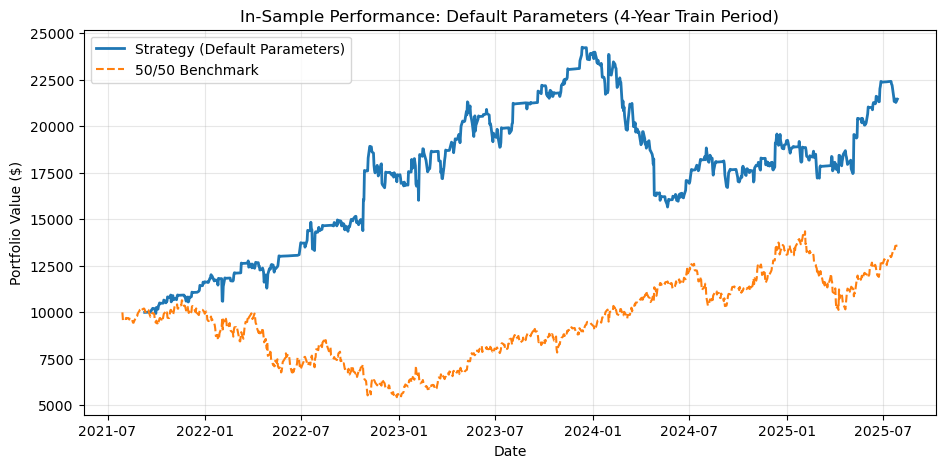

In [11]:
pos_ag = signals(z_ag, entry=1, exit=0.25)
growth_ag = returns(stock_x_logged, stock_y_logged, pos_ag, beta_ag)
print(growth_ag['Traded Position'].value_counts())
print(growth_ag.tail(5))

# Calculate the 50/50 benchmark for the training period.
px_tr, py_tr = np.exp(stock_x_logged), np.exp(stock_y_logged)
benchmark_tr = (5000 * (px_tr / px_tr.iloc[0])
                + 5000 * (py_tr / py_tr.iloc[0]))

plt.figure(figsize=(11, 5))
plt.plot(growth_ag['Portfolio Value'],
         label='Strategy (Default Parameters)', linewidth=2)
plt.plot(benchmark_tr, label='50/50 Benchmark',
         linestyle='--', linewidth=1.5)

plt.title('In-Sample Performance: Default Parameters '
          '(4-Year Train Period)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [12]:
# NOTE
# From here we attempt to backtest to find optimal parameter values.
# However, we note straight away that this leads to some overfitting
# and a significantly decreased PnL. The risk of the trades does
# dramatically decrease, and in order to capitalise on such a
# property we would need to implement trading over multiple pairs of
# stocks.


def metrics(returns_df, capital=10000, rf_annual=0.045):
    """Compute performance metrics used to test parameter values.

    Takes the dataframe outputted from returns() as input.
    """
    net_returns = returns_df['Net Return']
    portfolio_value = returns_df['Portfolio Value']
    traded_pos = returns_df['Traded Position']
    rf_daily = rf_annual / 252

    # Annualised Sharpe ratio: quantifies whether the returns are
    # worth the risk.
    r_mean = net_returns.mean()
    r_std = net_returns.std()
    sharpe = (((r_mean - rf_daily) / r_std * np.sqrt(252))
              if r_std > 0 else 0)

    # Net PnL.
    end = portfolio_value.iloc[-1]
    net_pnl = end - capital

    # Maximum drawdown: largest drop in portfolio value.
    p_max = portfolio_value.cummax()
    drawdown = (portfolio_value - p_max) / p_max
    max_drawdown = drawdown.min() * 100

    # Calmar ratio.
    years = len(returns_df) / 252
    c = (end / capital) ** (1 / years) - 1 if years > 0 else 0
    calmar = (c / (abs(max_drawdown) / 100)
              if abs(max_drawdown) > 0 else 0)

    # Trade execution: profitable days vs total trading days.
    active = net_returns[traded_pos != 0]
    total = len(active)
    if total > 0:
        win = (active > 0).sum()
        winrate = win / total * 100    # Win rate as a percentage
    elif total == 0:
        winrate = 0
    trades = ((traded_pos != 0)
              & (traded_pos.shift(1).fillna(0) == 0)).sum()

    return {
        'Net PnL': f'${net_pnl:,.2f}',
        'Ending Portfolio Value': f'${end:,.2f}',
        'Sharpe Ratio': round(sharpe, 2),
        'Calmar Ratio': round(calmar, 2),
        'Max Drawdown': f'{max_drawdown:.2f}%',
        'Win Rate': f'{winrate:.2f}%',
        'Total Trades': trades,
    }

def benchmark_metrics(bench):
    shim = pd.DataFrame({
        'Portfolio Value': bench,
        'Net Return': bench.pct_change().fillna(0.0),
        'Traded Position': 1,          # always invested
    }, index=bench.index)
    return metrics(shim)

In [13]:
pd.Series(metrics(growth_ag), name='Value')

Net PnL                   $11,462.81
Ending Portfolio Value    $21,462.81
Sharpe Ratio                     0.7
Calmar Ratio                    0.62
Max Drawdown                 -35.42%
Win Rate                      53.32%
Total Trades                      73
Name: Value, dtype: object

In [14]:
def parasearch(x_logged, y_logged, parameters, capital=10000, warmup=30,
               leverage=2, rf_annual=0.045, t_cost=0.001):
    """Compute metrics for a range of parameter values.

    Typical parameters to vary are the entry/exit thresholds, the
    lookback window (z_window) and the process noise variance
    (delta_beta), but the stop loss and delta_alpha can also be
    considered. All other parameters are kept at their defaults
    throughout the program.
    """
    # Create all parameter combinations.
    keys = list(parameters.keys())
    values = list(parameters.values())
    combos = [dict(zip(keys, v)) for v in it.product(*values)]
    results = []

    for combo in combos:
        combo_entry = combo.get('entry', 1)
        combo_exit = combo.get('exit', 0.25)
        combo_z_window = combo.get('z_window', 30)
        combo_delta_alpha = combo.get('delta_alpha', 1e-4)
        combo_delta_beta = combo.get('delta_beta', 1e-4)
        combo_stop = combo.get('stop', 3)

        alpha_s, beta_s, _, z_s, _ = kalman_filter(
            x_logged, y_logged,
            delta_alpha=combo_delta_alpha,
            delta_beta=combo_delta_beta,
            warmup=warmup,
            z_window=combo_z_window)
        pos_s = signals(z_s, entry=combo_entry, exit=combo_exit,
                        stop=combo_stop)
        returns_df = returns(x_logged, y_logged, pos_s, beta_s,
                             capital=capital, leverage=leverage,
                             rf_annual=rf_annual, t_cost=t_cost)
        tested_metrics = metrics(returns_df, capital=capital,
                                 rf_annual=rf_annual)

        row = {**combo, **tested_metrics}
        results.append(row)

    results_df = pd.DataFrame(results)
    return results_df

                       Max-SR training results Max-P&L training results
entry                                     2.25                     2.25
exit                                      0.25                      0.5
z_window                                    45                       45
delta_beta                              0.0001                    0.001
stop                                       3.5                      3.5
Net PnL                             $15,005.04               $11,265.69
Ending Portfolio Value              $25,005.04               $21,265.69
Sharpe Ratio                              1.29                     1.25
Calmar Ratio                              2.58                     3.05
Max Drawdown                           -10.56%                   -7.20%
Win Rate                                61.49%                   65.17%
Total Trades                                16                       20
Sharpe_num                                1.29                  

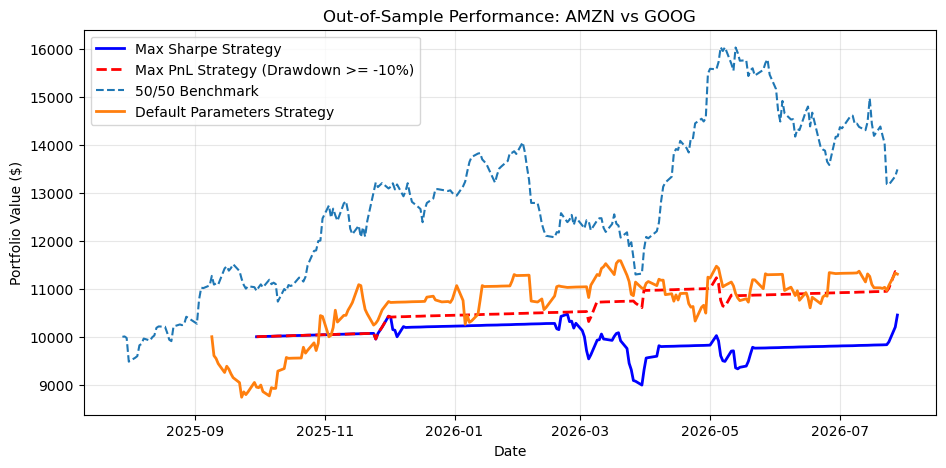

In [23]:
parameter_values = {
    'entry': [1.25, 1.50, 1.75, 2.00, 2.25],
    'exit': [0.0, 0.25, 0.50],
    'z_window': [10,15,20,25,30,45,60],
    'delta_beta': [1e-5, 1e-4, 1e-3],
    'stop': [3.0, 3.5, 4.0],
}
train_results = parasearch(stock_x_logged, stock_y_logged,
                           parameters=parameter_values)
test_stock_x_logged = test_matrix_log['AMZN']
test_stock_y_logged = test_matrix_log['GOOG']

# Extract the best parameter sets for max Sharpe and max PnL.
train_results['Sharpe_num'] = train_results['Sharpe Ratio'].astype(float)
train_results['PnL_num'] = (
    train_results['Net PnL']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float))
train_results['MDD_num'] = (
    train_results['Max Drawdown']
    .str.replace('%', '', regex=False)
    .astype(float))

def select_best_pnl(results, mdd_floor=-10.0, relax_step=5.0, mdd_min=-100.0):
    """Max Net PnL subject to a drawdown floor.

    If no parameter set clears `mdd_floor`, the floor is relaxed in steps of
    `relax_step` until something qualifies. If nothing qualifies at any level,
    falls back to the shallowest-drawdown set. Returns (params_dict, floor_used),
    where floor_used is None if the constraint was abandoned entirely.
    """
    if results.empty:
        raise ValueError("parasearch returned no results — nothing to select from.")

    floor = mdd_floor
    while floor >= mdd_min:
        eligible = results[results['MDD_num'] >= floor]
        if not eligible.empty:
            if floor != mdd_floor:
                warnings.warn(
                    f"No parameter set met MDD >= {mdd_floor}%. "
                    f"Relaxed to MDD >= {floor}% ({len(eligible)} candidates).",
                    RuntimeWarning,
                )
            best = eligible.sort_values('PnL_num', ascending=False).iloc[0]
            return best.to_dict(), floor
        floor -= relax_step

    warnings.warn(
        "No parameter set met any drawdown constraint; "
        "falling back to the shallowest drawdown.",
        RuntimeWarning,
    )
    best = results.sort_values(['MDD_num', 'PnL_num'], ascending=[False, False]).iloc[0]
    return best.to_dict(), None

best_sharpe = (train_results
               .sort_values('Sharpe_num', ascending=False)
               .iloc[0].to_dict())
best_pnl, mdd_floor_used = select_best_pnl(train_results, mdd_floor=-10.0)

summary_train = pd.DataFrame({
    'Max-SR training results':  best_sharpe,
    'Max-P&L training results': best_pnl,
})
print(summary_train)

def run_test_strategy(params, train_x, train_y, test_x, test_y):
    """Run a parameter set out of sample, seeded by the train state."""
    w = int(params['z_window'])
    _, _, _, _, train_state = kalman_filter(
        train_x, train_y, delta_beta=params['delta_beta'], z_window=w)
    a_ts, b_ts, _, z_ts, _ = kalman_filter(
        test_x, test_y, delta_beta=params['delta_beta'], z_window=w,
        warmup=0, **train_state)
    pos_ts = signals(z_ts, entry=params['entry'], exit=params['exit'],
                     stop=params['stop'])

    return returns(test_x, test_y, pos_ts, b_ts,
                   capital=10000)


# Run backtests.
ret_sharpe = run_test_strategy(best_sharpe, stock_x_logged,
                               stock_y_logged, test_stock_x_logged,
                               test_stock_y_logged)

ret_pnl = run_test_strategy(best_pnl, stock_x_logged, stock_y_logged,
                            test_stock_x_logged, test_stock_y_logged)


# Compute the 50/50 benchmark.
px, py = np.exp(test_stock_x_logged), np.exp(test_stock_y_logged)
benchmark = 5000 * (px / px.iloc[0]) + 5000 * (py / py.iloc[0])

summary_test = pd.DataFrame({
    'Max-SR testing results':  metrics(ret_sharpe),
    'Max-P&L testing results': metrics(ret_pnl),
    'Benchmark training results': benchmark_metrics(benchmark_tr),
    'Benchmark testing results': benchmark_metrics(benchmark),
})
print(summary_test)


plt.figure(figsize=(11, 5))
plt.plot(ret_sharpe['Portfolio Value'], label='Max Sharpe Strategy', color='blue',
         linewidth=2)

pnl_label = (f'Max PnL Strategy (Drawdown >= {mdd_floor_used:.0f}%)'
             if mdd_floor_used is not None
             else 'Max PnL Strategy (unconstrained)')
plt.plot(ret_pnl['Portfolio Value'], label=pnl_label,
         color='red', linestyle='--', linewidth=2)

#plt.plot(ret_pnl['Portfolio Value'], label='Max PnL Strategy (Drawdown >= -10%)',
         #color='red', linestyle='--', linewidth=2)
plt.plot(benchmark, label='50/50 Benchmark', linestyle='--',
         linewidth=1.5)

alpha_AG, beta_AG, spread_AG, z_AG, end_AG = kalman_filter(
    test_stock_x_logged, test_stock_y_logged)
pos_AG = signals(z_AG, entry=1, exit=0.25)
growth_AG = returns(test_stock_x_logged, test_stock_y_logged, pos_AG, beta_AG)
plt.plot(growth_AG['Portfolio Value'],
         label='Default Parameters Strategy', linewidth=2)

plt.title('Out-of-Sample Performance: AMZN vs GOOG')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()